In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import joblib
import matplotlib.pyplot as plt

In [2]:
model_data = pd.read_csv("../data/processed/model_data_with_rankings.csv")

model_data.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,result,...,attack_difference,defense_difference,home_rank_date,home_team_rank,home_team_rank_points,away_rank_date,away_team_rank,away_team_rank_points,rank_difference,rank_points_difference
0,1970-01-04,Malta,Luxembourg,1.0,1.0,Friendly,Gżira,Malta,False,Draw,...,0.0,-2.2,1970-01-01 00:00:00.000002024,169.0,983.95,1970-01-01 00:00:00.000002024,92.0,1256.42,-77.0,-272.47
1,1970-01-14,England,Netherlands,0.0,0.0,Friendly,London,England,False,Draw,...,0.8,-0.2,1970-01-01 00:00:00.000002024,4.0,1813.81,1970-01-01 00:00:00.000002024,7.0,1747.55,3.0,66.26
2,1970-01-28,Israel,Netherlands,0.0,1.0,Friendly,Jaffa,Israel,False,Away Win,...,1.2,0.0,1970-01-01 00:00:00.000002024,76.0,1322.25,1970-01-01 00:00:00.000002024,7.0,1747.55,-69.0,-425.30
3,1970-02-04,Peru,Czechoslovakia,0.0,2.0,Friendly,Lima,Peru,False,Away Win,...,-0.6,-0.4,1970-01-01 00:00:00.000002024,40.0,1488.42,1970-01-01 00:00:00.000001993,19.0,49.00,-21.0,1439.42
4,1970-02-06,Sudan,Ethiopia,3.0,0.0,African Cup of Nations,Khartoum,Sudan,False,Home Win,...,-1.0,0.4,1970-01-01 00:00:00.000002024,113.0,1165.41,1970-01-01 00:00:00.000002024,146.0,1059.94,33.0,105.47


In [3]:
model_data.columns

Index(['date', 'home_team', 'away_team', 'home_score', 'away_score',
       'tournament', 'city', 'country', 'neutral', 'result', 'result_label',
       'home_recent_win_rate', 'home_recent_avg_goals_scored',
       'home_recent_avg_goals_conceded', 'away_recent_win_rate',
       'away_recent_avg_goals_scored', 'away_recent_avg_goals_conceded',
       'win_rate_difference', 'attack_difference', 'defense_difference',
       'home_rank_date', 'home_team_rank', 'home_team_rank_points',
       'away_rank_date', 'away_team_rank', 'away_team_rank_points',
       'rank_difference', 'rank_points_difference'],
      dtype='object')

In [4]:
features = [
    "home_recent_win_rate",
    "home_recent_avg_goals_scored",
    "home_recent_avg_goals_conceded",
    "away_recent_win_rate",
    "away_recent_avg_goals_scored",
    "away_recent_avg_goals_conceded",
    "win_rate_difference",
    "attack_difference",
    "defense_difference",
    "neutral",
    "home_team_rank",
    "away_team_rank",
    "home_team_rank_points",
    "away_team_rank_points",
    "rank_difference",
    "rank_points_difference"
]

target = "result_label"

X = model_data[features]
y = model_data[target]

In [5]:
X = X.fillna(0)

In [6]:
X.isnull().sum()

home_recent_win_rate              0
home_recent_avg_goals_scored      0
home_recent_avg_goals_conceded    0
away_recent_win_rate              0
away_recent_avg_goals_scored      0
away_recent_avg_goals_conceded    0
win_rate_difference               0
attack_difference                 0
defense_difference                0
neutral                           0
home_team_rank                    0
away_team_rank                    0
home_team_rank_points             0
away_team_rank_points             0
rank_difference                   0
rank_points_difference            0
dtype: int64

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [8]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

log_predictions = log_model.predict(X_test)

log_accuracy = accuracy_score(y_test, log_predictions)

log_accuracy

C:\Users\kshit\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.5637247679387064

In [9]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    max_depth=12
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_predictions)

rf_accuracy

0.5690290260792692

In [10]:
print("Logistic Regression Accuracy:", log_accuracy)
print("Random Forest Accuracy:", rf_accuracy)

Logistic Regression Accuracy: 0.5637247679387064
Random Forest Accuracy: 0.5690290260792692


In [11]:
print(classification_report(y_test, rf_predictions))

              precision    recall  f1-score   support

          -1       0.53      0.55      0.54      1872
           0       0.29      0.02      0.04      1641
           1       0.60      0.85      0.70      3274

    accuracy                           0.57      6787
   macro avg       0.47      0.48      0.43      6787
weighted avg       0.50      0.57      0.50      6787



In [12]:
feature_importance = pd.DataFrame({
    "feature": features,
    "importance": rf_model.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance

,feature,importance
14,rank_difference,0.191014
15,rank_points_difference,0.169685
8,defense_difference,0.077492
11,away_team_rank,0.062867
10,home_team_rank,0.060966
13,away_team_rank_points,0.060845
12,home_team_rank_points,0.055739
7,attack_difference,0.054600
2,home_recent_avg_goals_conceded,0.046595
5,away_recent_avg_goals_conceded,0.044989


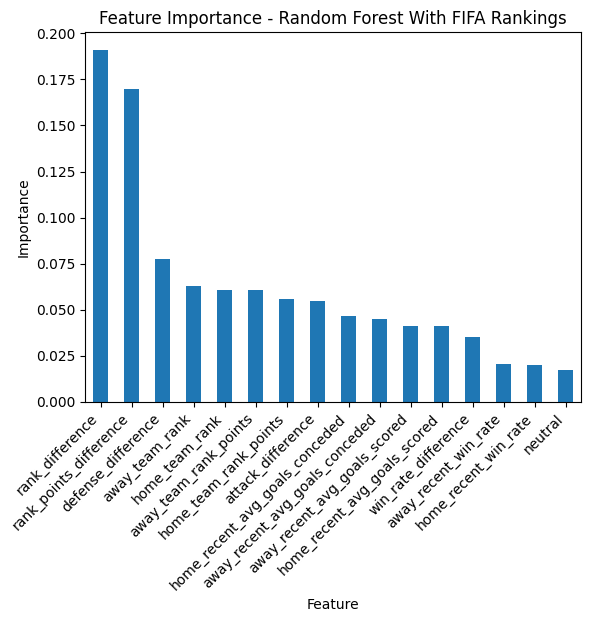

In [13]:
feature_importance.plot(
    kind="bar",
    x="feature",
    y="importance",
    legend=False
)

plt.title("Feature Importance - Random Forest With FIFA Rankings")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.show()

In [14]:
joblib.dump(rf_model, "../models/world_cup_predictor_model_ranked.pkl")
joblib.dump(features, "../models/model_features_ranked.pkl")

['../models/model_features_ranked.pkl']

In [15]:
sample_match = pd.DataFrame([{
    "home_recent_win_rate": 0.60,
    "home_recent_avg_goals_scored": 2.0,
    "home_recent_avg_goals_conceded": 1.0,
    "away_recent_win_rate": 0.40,
    "away_recent_avg_goals_scored": 1.4,
    "away_recent_avg_goals_conceded": 1.2,
    "win_rate_difference": 0.20,
    "attack_difference": 0.60,
    "defense_difference": -0.20,
    "neutral": True,
    "home_team_rank": 1,
    "away_team_rank": 5,
    "home_team_rank_points": 1850,
    "away_team_rank_points": 1750,
    "rank_difference": 4,
    "rank_points_difference": 100
}])

In [16]:
rf_model.predict(sample_match)

array([1], dtype=int64)

In [17]:
probabilities = rf_model.predict_proba(sample_match)[0]

prediction_output = pd.DataFrame({
    "Result": rf_model.classes_,
    "Probability": probabilities
})

prediction_output

,Result,Probability
0,-1,0.243142
1,0,0.343171
2,1,0.413687
